https://github.com/destination-earth-digital-twins/polytope-examples/blob/main/climate-dt/explorer/04_lazy_browse_portfolio_hourly.ipynb

In [1]:
%%capture cap
%run ../src/desp-authentication.py -u "" -p ""

In [2]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

In [3]:
S3_KEY = ""
S3_SECRET = ""

In [23]:
import earthkit.data
import earthkit.plots
import earthkit.geo.cartography

import logging, warnings
import earthkit.data

# Disable earthkit disk cache (polytope_zarr caches decoded arrays in memory)
earthkit.data.config.set("cache-policy", "off")

# Silence verbose output from polytope / earthkit internals
for _ln in ("polytope", "polytope.api", "earthkit.data", "urllib3"):
    logging.getLogger(_ln).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from polytope_zarr import PolytopeZarrStore

import s3fs
import io

import xarray as xr
import earthkit.plots as ekp



In [5]:
# Defaults to making a live data request. Set to false to use the cached GRIB file instead.
import os

LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"
LIVE_REQUEST

True

In [8]:
eodc_s3 = s3fs.S3FileSystem(
    key=S3_KEY,
    secret=S3_SECRET,
    client_kwargs={
        "endpoint_url": "https://objects.eodc.eu"
    })

path = "destine-climate-dt/lsm/netcdf"

### Realization 1

In [9]:
realization="1"

story_store1 = PolytopeZarrStore.from_climate_dt(
    models=["IFS-FESOM"],
    experiment=["cont", "hist", "Tplus2.0K"],
    activity="story-nudging",
    levtype="sfc",
    frequency="daily",
    start_date="2017-01-01T00:00:00",
    end_date="2025-12-31T23:00:00",
    resolution="high",
    realization=realization,
)
print(story_store1)
story_store1._filter_hours = [12]

<PolytopeZarrStore 34 variables (time=78888, cell=3145728, climate=3)>


In [10]:
ds_story1 = story_store1.open()
ds_story1

<xarray.Dataset> Size: 101TB
Dimensions:       (climate: 3, time: 78888, cell: 3145728)
Coordinates:
  * cell          (cell) int32 13MB 0 1 2 3 ... 3145724 3145725 3145726 3145727
  * climate       (climate) object 24B 'cont' 'hist' 'Tplus2.0K'
  * time          (time) datetime64[ns] 631kB 2017-01-01 ... 2025-12-31T23:00:00
Data variables: (12/34)
    10si          (climate, time, cell) float32 3TB ...
    10u           (climate, time, cell) float32 3TB ...
    10v           (climate, time, cell) float32 3TB ...
    2d            (climate, time, cell) float32 3TB ...
    2t            (climate, time, cell) float32 3TB ...
    avg_ie        (climate, time, cell) float32 3TB ...
    ...            ...
    sp            (climate, time, cell) float32 3TB ...
    tcc           (climate, time, cell) float32 3TB ...
    tciw          (climate, time, cell) float32 3TB ...
    tclw          (climate, time, cell) float32 3TB ...
    tcw           (climate, time, cell) float32 3TB ...
    tcwv          (climate, time, cell) float32 3TB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=78888, cell=31457...

In [12]:
import earthkit.geo.cartography

COUNTRY = "Austria"
shapes = earthkit.geo.cartography.country_polygons([COUNTRY], resolution=50e6)

In [ ]:
climate = "cont"

vsw_cont_by_level = {}
for level in [1]:
    vsw_cont = ds_story1["msl"].polytope.sel(
        climate=climate, time="2025-01-01",
        level=level, polygon=shapes,
    )
    data_bytes = vsw_cont.to_netcdf()  # no path → returns bytes
    with eodc_s3.open(f"{path}/vsw_story-nudging_{climate}_r{realization}.nc", "wb") as f:
        f.write(data_bytes)
        print(f"{path}/vsw_story-nudging_{climate}_r{realization}.nc")

  🌍 polygon request for msl (20250101)


destine-climate-dt/lsm/netcdf/vsw_story-nudging_cont_level1_r1.nc


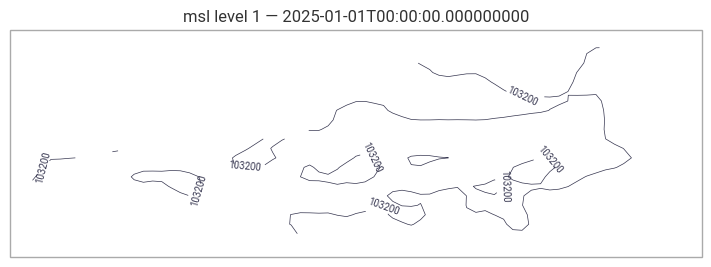

In [ ]:
with eodc_s3.open(f"{path}/vsw_story-nudging_{climate}_r{realization}.nc", "rb") as f:
    ds_check = xr.open_dataset(io.BytesIO(f.read()))

ekp.quickplot(
    ds_check["msl"],
    title=f"msl level {level} — {ds_check['time'].isel(time=0).values}",
)


In [28]:
climate = "hist"

vsw_cont_by_level = {}
for level in [1]:
    vsw_cont = ds_story1["msl"].polytope.sel(
        climate=climate, time="2025-12-01",
        level=level, polygon=shapes,
    )
    data_bytes = vsw_cont.to_netcdf()  # no path → returns bytes
    with eodc_s3.open(f"{path}/vsw_story-nudging_{climate}_r{realization}.nc", "wb") as f:
        f.write(data_bytes)
        print(f"{path}/vsw_story-nudging_{climate}_r{realization}.nc")

  🌍 polygon request for msl (20251201)


destine-climate-dt/lsm/netcdf/vsw_story-nudging_hist_r1.nc


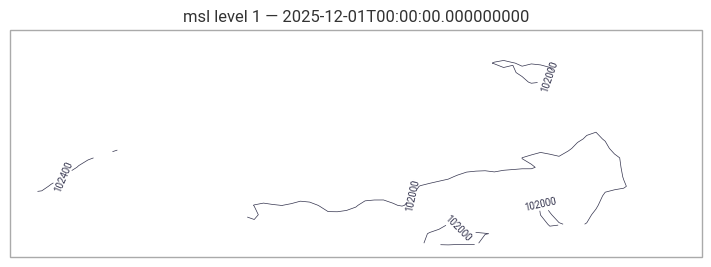

In [29]:
with eodc_s3.open(f"{path}/vsw_story-nudging_{climate}_r{realization}.nc", "rb") as f:
    ds_check = xr.open_dataset(io.BytesIO(f.read()))

ekp.quickplot(
    ds_check["msl"],
    title=f"msl level {level} — {ds_check['time'].isel(time=0).values}",
)

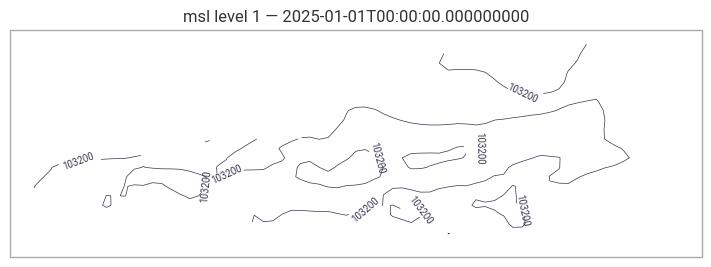

In [25]:
with eodc_s3.open(f"{path}/vsw_story-nudging_{climate}_r{realization}.nc", "rb") as f:
    ds_check = xr.open_dataset(io.BytesIO(f.read()))

ekp.quickplot(
    ds_check["msl"],
    title=f"msl level {level} — {ds_check['time'].isel(time=0).values}",
)

In [26]:
climate = "Tplus2.0K"

vsw_cont_by_level = {}
for level in [1]:
    vsw_cont = ds_story1["msl"].polytope.sel(
        climate=climate, time="2025-01-01",
        level=level, polygon=shapes,
    )
    data_bytes = vsw_cont.to_netcdf()  # no path → returns bytes
    with eodc_s3.open(f"{path}/vsw_story-nudging_{climate}_r{realization}.nc", "wb") as f:
        f.write(data_bytes)
        print(f"{path}/vsw_story-nudging_{climate}_r{realization}.nc")

  🌍 polygon request for msl (20250101)


destine-climate-dt/lsm/netcdf/vsw_story-nudging_Tplus2.0K_r1.nc


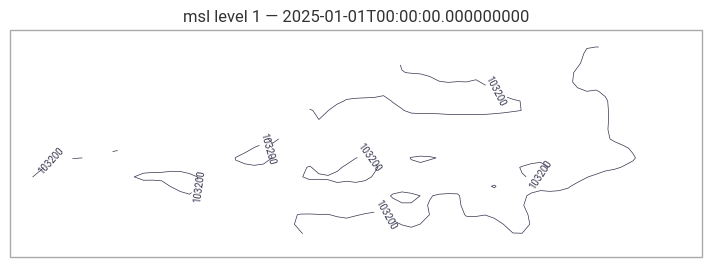

In [27]:
with eodc_s3.open(f"{path}/vsw_story-nudging_{climate}_r{realization}.nc", "rb") as f:
    ds_check = xr.open_dataset(io.BytesIO(f.read()))

ekp.quickplot(
    ds_check["msl"],
    title=f"msl level {level} — {ds_check['time'].isel(time=0).values}",
)

# IFS-FESOM

In [47]:
                   #  2 vars — height levels (100 m, IFS-only)
LEVTYPE = "sfc"                  #  2 vars — soil / snow


store = PolytopeZarrStore.from_climate_dt(
    models=["IFS-FESOM"],
    experiment="hist",
    resolution="high", # 'standard', 'high'
    levtype=LEVTYPE,
    frequency="hourly",
    start_date="2010-01-01T00:00:00",
    end_date="2014-12-31T23:00:00",
)
print(store)

<PolytopeZarrStore 34 variables (time=43824, cell=12582912, model=1)>


In [48]:
ds = store.open()
ds

<xarray.Dataset> Size: 75TB
Dimensions:       (model: 1, time: 43824, cell: 12582912)
Coordinates:
  * cell          (cell) int32 50MB 0 1 2 3 ... 12582909 12582910 12582911
  * model         (model) object 8B 'IFS-FESOM'
  * time          (time) datetime64[ns] 351kB 2010-01-01 ... 2014-12-31T23:00:00
Data variables: (12/34)
    10si          (model, time, cell) float32 2TB ...
    10u           (model, time, cell) float32 2TB ...
    10v           (model, time, cell) float32 2TB ...
    2d            (model, time, cell) float32 2TB ...
    2t            (model, time, cell) float32 2TB ...
    avg_ie        (model, time, cell) float32 2TB ...
    ...            ...
    sp            (model, time, cell) float32 2TB ...
    tcc           (model, time, cell) float32 2TB ...
    tciw          (model, time, cell) float32 2TB ...
    tclw          (model, time, cell) float32 2TB ...
    tcw           (model, time, cell) float32 2TB ...
    tcwv          (model, time, cell) float32 2TB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=43824, cell=12582...

In [46]:

from destine_portfolio import find_variable, access_snippet


find_variable("lsm")
find_variable("orog")

""


In [53]:
find_variable("vsw")

,stream/activity,shortName,levtype,freq,access,long_name,units,models,experiments,nside
0,clmn,avg_vsw,sol,monthly,monthly/sol,Time-mean volumetric soil moisture,m**3 m**-3,"IFS-NEMO, IFS-FESOM, ICON","cont, hist, SSP3-7.0","{'standard': 128, 'high': 1024}"
1,clte,vsw,sol,hourly,hourly/sol,Volumetric soil moisture,m**3 m**-3,"IFS-NEMO, IFS-FESOM, ICON","cont, hist, SSP3-7.0","{'standard': 128, 'high': 1024}"
2,storyline,vsw,sol,hourly,hourly (storyline)/sol,Volumetric soil moisture,m**3 m**-3,IFS-FESOM,"cont, hist, Tplus2.0K","{'standard': 128, 'high': 512}"
